# Part 3 — Batched → Increase Accuracy (Step 1)

**Question:** can we recover unbatched-tier accuracy at batched-tier cost by changing the value-evaluator's question?

* **`--focused`** — replace per-clue verdicts with a single candidate-level `viable`/`not_viable`. Tune `--top_k ∈ {0, 3, 5, 7}` (0 = all testable clues).

**Data:** 4 runs per cell on the 20-puzzle paper split.

**Reference points** (carried from Part 2): `full_basic` 24.0%, `half_basic` 26.3%, `unbatched` 35.0%.

In [38]:
import json, glob, statistics
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# Walk up from cwd to the repo root (where 'results/' and 'data/' live).
# Robust to Jupyter being launched from the notebook dir or the repo root.
ROOT = Path.cwd().resolve()
while not ((ROOT / 'results').is_dir() and (ROOT / 'data').is_dir()):
    if ROOT == ROOT.parent:
        raise RuntimeError(f"can't find repo root from {Path.cwd()}")
    ROOT = ROOT.parent
RUNS = ROOT / 'results' / 'crosswords' / 'runs'
assert RUNS.is_dir()

# ---------------- Report palette ----------------
CHARCOAL = '#233d4d'   # primary dark
PUMPKIN  = '#fe7f2d'   # accent / highlight (full batch)
GOLDEN   = '#fcca46'   # warm secondary
OLIVE    = '#a1c181'   # muted secondary
SEAGRASS = '#619b8a'   # cool secondary (half batch)

LEVEL_COLOR = {'Full batch': PUMPKIN, 'Half batch': SEAGRASS, 'Unbatched': CHARCOAL}

mpl.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'white',
    'axes.edgecolor':CHARCOAL,'axes.labelcolor':CHARCOAL,'axes.titlecolor':CHARCOAL,
    'axes.titleweight':'bold','axes.labelweight':'bold',
    'axes.titlesize':14,'axes.labelsize':12,'axes.linewidth':1.6,
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':False,
    'xtick.color':CHARCOAL,'ytick.color':CHARCOAL,
    'xtick.labelsize':11,'ytick.labelsize':11,
    'xtick.major.size':0,'ytick.major.size':4,
    'font.weight':'bold','font.family':'sans-serif',
    'legend.frameon':False,'legend.fontsize':11,
    'lines.linewidth':2.6,'lines.markersize':9,
    'savefig.dpi':180,'savefig.bbox':'tight',
})

## 1. Helpers

In [39]:
def grid_metrics(grid, gt):
    flat = [c.upper() for r in grid for c in r]
    truth = [c.upper() for c in gt]
    if len(flat) != 25: return 0.0, 0.0, 0.0
    cl = sum(1 for o, t in zip(flat, truth) if o == t)
    cw = sum(1 for i in range(5) if flat[i*5:(i+1)*5] == truth[i*5:(i+1)*5])
    cw += sum(1 for i in range(5) if flat[i::5] == truth[i::5])
    return cl/25, cw/10, 1.0 if cl == 25 else 0.0

def load_runs(pattern, expected_n=20):
    out = []
    for fp in sorted(glob.glob(str(RUNS/pattern))):
        with open(fp) as f:
            rows = [json.loads(line) for line in f if line.strip()]
        if len(rows) >= expected_n:
            out.append({'file': Path(fp).name, 'rows': rows})
    return out

def run_metrics(rows):
    Ls, Ws, Gs, Ss, Cs = [], [], [], [], []
    for r in rows:
        l, w, g = grid_metrics(r['grid'], r['ground_truth'])
        Ls.append(l); Ws.append(w); Gs.append(g)
        Ss.append(r.get('expansions', 0))
        Cs.append(r.get('llm_calls_total', 0))
    return {
        'letter': statistics.mean(Ls)*100,
        'word':   statistics.mean(Ws)*100,
        'game':   statistics.mean(Gs)*100,
        'steps':  statistics.mean(Ss),
        'calls':  statistics.mean(Cs),
    }

def aggregate(runs, label):
    if not runs: return None
    per_run = [run_metrics(r['rows']) for r in runs]
    out = {'label': label, 'n_runs': len(per_run), 'per_run': per_run}
    for k in ('letter', 'word', 'game', 'steps', 'calls'):
        vs = [m[k] for m in per_run]
        out[f'{k}_mean'] = statistics.mean(vs)
        out[f'{k}_se']   = statistics.pstdev(vs)/(len(vs)**0.5) if len(vs) > 1 else 0.0
        out[f'{k}_runs'] = vs
    return out

## 2. Load every Part-3 cell + reference points

In [40]:
cells = {
    # full batch
    'full_basic':       aggregate(load_runs('cw_gem31_tot_full_basic_s100_prune_backtrack_papersplit*.jsonl'),    'full_basic'),
    'full_focused_k0':  aggregate(load_runs('cw_gem31_tot_full_focused_s100_prune_backtrack_papersplit*.jsonl'),  'full_focused'),
    'full_focused_k3':  aggregate(load_runs('cw_gem31_tot_full_focused_k3_s100_prune_backtrack_papersplit*.jsonl'),'full_focused_k3'),
    'full_focused_k5':  aggregate(load_runs('cw_gem31_tot_full_focused_k5_s100_prune_backtrack_papersplit*.jsonl'),'full_focused_k5'),
    'full_focused_k7':  aggregate(load_runs('cw_gem31_tot_full_focused_k7_s100_prune_backtrack_papersplit*.jsonl'),'full_focused_k7'),
    'full_verified':    aggregate(load_runs('cw_gem31_tot_full_verified_s100_prune_backtrack_papersplit*.jsonl'),  'full_verified'),
    # half batch
    'half_basic':       aggregate(load_runs('cw_gem31_tot_half_basic_s100_prune_backtrack_papersplit*.jsonl'),    'half_basic'),
    'half_focused_k0':  aggregate(load_runs('cw_gem31_tot_half_focused_s100_prune_backtrack_papersplit*.jsonl'),  'half_focused'),
    'half_focused_k3':  aggregate(load_runs('cw_gem31_tot_half_focused_k3_s100_prune_backtrack_papersplit*.jsonl'),'half_focused_k3'),
    'half_focused_k5':  aggregate(load_runs('cw_gem31_tot_half_focused_k5_s100_prune_backtrack_papersplit*.jsonl'),'half_focused_k5'),
    'half_focused_k7':  aggregate(load_runs('cw_gem31_tot_half_focused_k7_s100_prune_backtrack_papersplit*.jsonl'),'half_focused_k7'),
    'half_verified':    aggregate(load_runs('cw_gem31_tot_half_verified_s100_prune_backtrack_papersplit*.jsonl'), 'half_verified'),
    # reference
    'unbatched':        aggregate(load_runs('cw_gem31_tot_unbatched_s100_prune_backtrack_papersplit*.jsonl'),    'unbatched'),
}

print(f'{"cell":22s}{"runs":>5}{"L%":>9}{"W%":>9}{"G%":>11}{"calls":>8}{"steps":>8}')
print('-'*72)
for k, c in cells.items():
    if c is None:
        print(f'{k:22s}  no data'); continue
    print(f'{k:22s}{c["n_runs"]:>5}'
          f'  {c["letter_mean"]:>5.1f}'
          f'  {c["word_mean"]:>5.1f}'
          f'  {c["game_mean"]:>5.1f}±{c["game_se"]:.1f}'
          f'  {c["calls_mean"]:>5.0f}'
          f'  {c["steps_mean"]:>5.1f}')

cell                   runs       L%       W%         G%   calls   steps
------------------------------------------------------------------------
full_basic                5   72.7   50.6   24.0±2.2    158   26.9
full_focused_k0           4   74.8   54.0   27.5±2.8    118   19.6
full_focused_k3           4   71.8   50.1   26.2±2.7    143   23.7
full_focused_k5           3   71.3   48.8   21.7±1.4    115   19.1
full_focused_k7           3   76.0   52.0   20.0±4.1    111   18.4
full_verified             4   73.4   51.6   23.8±2.7    188   18.6
half_basic                5   77.6   55.6   25.0±1.4    414   37.2
half_focused_k0           4   79.3   60.1   36.2±2.1    397   27.5
half_focused_k3           3   75.3   55.0   30.0±6.2    467   32.6
half_focused_k5           2   79.4   58.8   30.0±0.0    478   32.3
half_focused_k7           3   82.0   63.2   38.3±3.6    400   28.2
half_verified             4   71.8   53.5   28.8±2.1    427   24.4
unbatched                 4   76.6   59.1   35.0±1

## 3. Plots


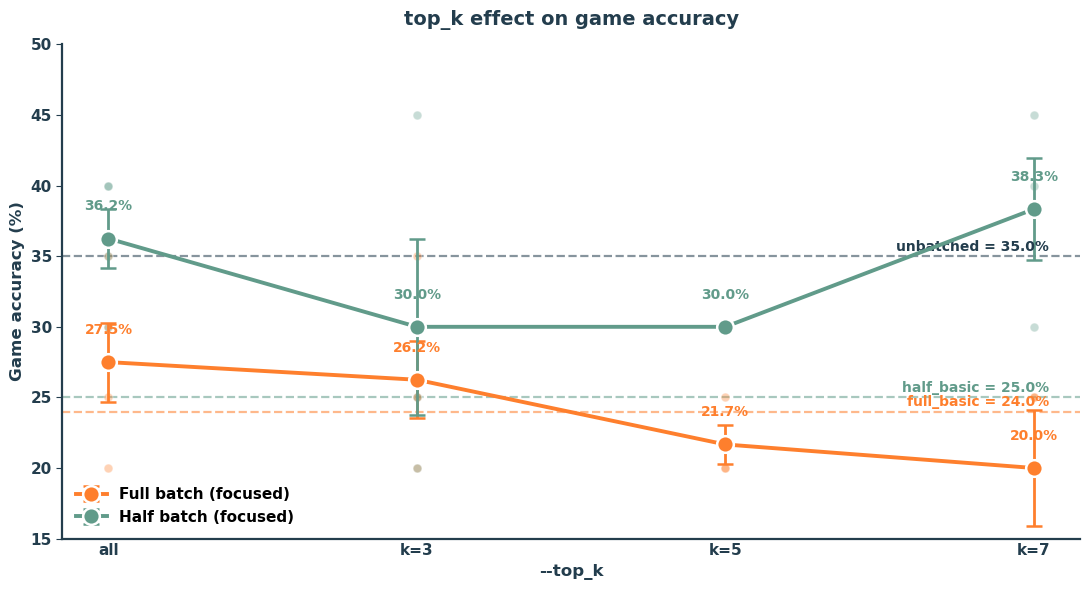

In [41]:
ks = [0, 3, 5, 7]

def curve(prefix):
    means, ses, runs = [], [], []
    for k in ks:
        key = f'{prefix}_k{k}' if k > 0 else f'{prefix}_k0'
        c = cells.get(key)
        if c is None:
            means.append(np.nan); ses.append(0); runs.append([])
        else:
            means.append(c['game_mean']); ses.append(c['game_se']); runs.append(c['game_runs'])
    return means, ses, runs

full_m, full_se, full_runs_per_k = curve('full_focused')
half_m, half_se, half_runs_per_k = curve('half_focused')

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(ks))

ax.errorbar(x, full_m, yerr=full_se, color=PUMPKIN, marker='o',
            markersize=12, markeredgecolor='white', markeredgewidth=1.8,
            linewidth=2.8, capsize=6, elinewidth=2,
            zorder=3, label='Full batch (focused)')
ax.errorbar(x, half_m, yerr=half_se, color=SEAGRASS, marker='o',
            markersize=12, markeredgecolor='white', markeredgewidth=1.8,
            linewidth=2.8, capsize=6, elinewidth=2,
            zorder=3, label='Half batch (focused)')
for xi, m, vs in zip(x, full_m, full_runs_per_k):
    if vs:
        ax.scatter([xi]*len(vs), vs, s=40, color=PUMPKIN, alpha=0.35,
                   edgecolor='white', linewidth=0.8, zorder=2)
    if not np.isnan(m):
        ax.text(xi, m + 2.0, f'{m:.1f}%', ha='center', fontsize=10,
                color=PUMPKIN, fontweight='bold')
for xi, m, vs in zip(x, half_m, half_runs_per_k):
    if vs:
        ax.scatter([xi]*len(vs), vs, s=40, color=SEAGRASS, alpha=0.35,
                   edgecolor='white', linewidth=0.8, zorder=2)
    if not np.isnan(m):
        ax.text(xi, m + 2.0, f'{m:.1f}%', ha='center', fontsize=10,
                color=SEAGRASS, fontweight='bold')

# Reference lines
for label, color, m in [
    ('full_basic',  PUMPKIN,  cells['full_basic']['game_mean']),
    ('half_basic',  SEAGRASS, cells['half_basic']['game_mean']),
    ('unbatched',   CHARCOAL, cells['unbatched']['game_mean']),
]:
    ax.axhline(m, color=color, linestyle='--', linewidth=1.6, alpha=0.55, zorder=1)
    ax.text(len(ks) - 0.95, m + 0.4, f'{label} = {m:.1f}%',
            color=color, fontsize=10, fontweight='bold', ha='right')

ax.set_xticks(x)
ax.set_xticklabels(['all', 'k=3', 'k=5', 'k=7'])
ax.set_xlabel('--top_k')
ax.set_ylabel('Game accuracy (%)')
ax.set_title('top_k effect on game accuracy', pad=14)
ax.set_ylim(15, 50)
ax.legend(loc='lower left')
fig.tight_layout()
plt.show()

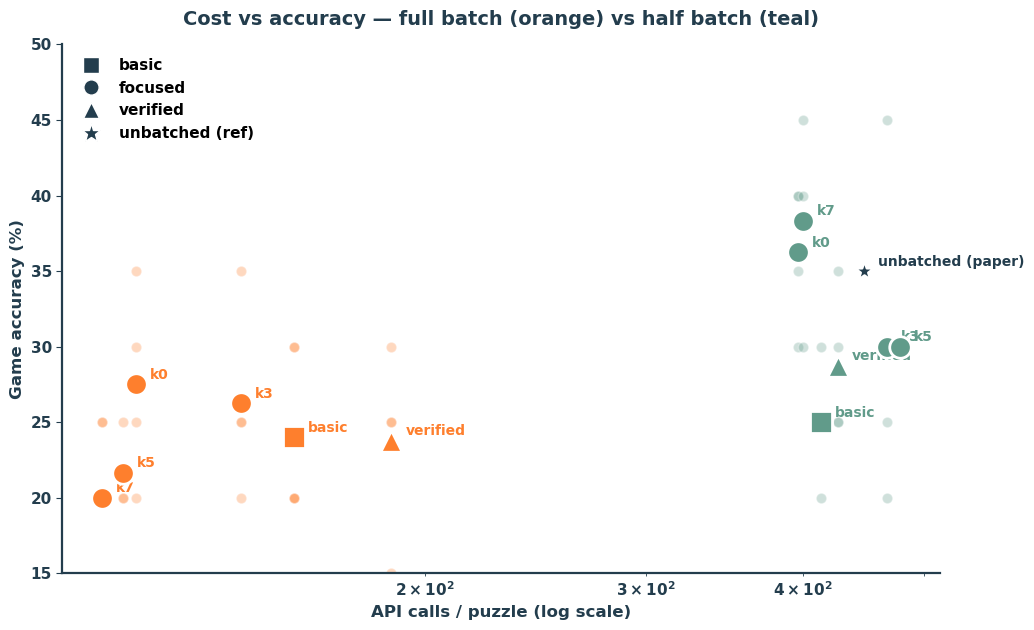

In [43]:
marker_for = {'basic':'s', 'focused':'o', 'verified':'^'}

def parse(label):
    parts = label.split('_')
    level = parts[0]
    kind  = parts[1]  # basic / focused / verified
    k = None
    if 'focused' in label and label.endswith(('k3','k5','k7')):
        k = int(label[-1])
    elif 'focused' in label:
        k = 0
    return level, kind, k

fig, ax = plt.subplots(figsize=(10.5, 6.4))
for key, c in cells.items():
    if c is None or key == 'unbatched': continue
    level, kind, k = parse(key)
    color = PUMPKIN if level == 'full' else SEAGRASS
    marker = marker_for[kind]
    label_runs = c['game_runs']
    ax.scatter([c['calls_mean']]*len(label_runs), label_runs,
               s=55, color=color, alpha=0.30, edgecolor='white', zorder=2)
    ax.scatter(c['calls_mean'], c['game_mean'], s=240, color=color,
               marker=marker, edgecolor='white', linewidth=2.0, zorder=4)
    txt = key.replace(f'{level}_', '').replace('focused_', '').replace('focused', 'focused (all)')
    ax.annotate(txt, (c['calls_mean'], c['game_mean']),
                xytext=(10, 4), textcoords='offset points',
                fontsize=10, color=color, fontweight='bold')

# Reference: unbatched
u = cells['unbatched']
ax.scatter(u['calls_mean'], u['game_mean'], s=240, color=CHARCOAL,
           marker='*', edgecolor='white', linewidth=2.0, zorder=4)
ax.annotate('unbatched (paper)', (u['calls_mean'], u['game_mean']),
            xytext=(10, 4), textcoords='offset points',
            fontsize=10, color=CHARCOAL, fontweight='bold')

# Legend
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0],[0], marker='s', color='w', markerfacecolor=CHARCOAL, markersize=11, label='basic'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=CHARCOAL, markersize=11, label='focused'),
    Line2D([0],[0], marker='^', color='w', markerfacecolor=CHARCOAL, markersize=11, label='verified'),
    Line2D([0],[0], marker='*', color='w', markerfacecolor=CHARCOAL, markersize=14, label='unbatched (ref)'),
]
ax.legend(handles=legend_handles, loc='upper left')

ax.set_xscale('log')
ax.set_xlabel('API calls / puzzle (log scale)')
ax.set_ylabel('Game accuracy (%)')
ax.set_title('Cost vs accuracy — full batch (orange) vs half batch (teal)', pad=14)
ax.set_ylim(15, 50)
fig.tight_layout()
plt.show()

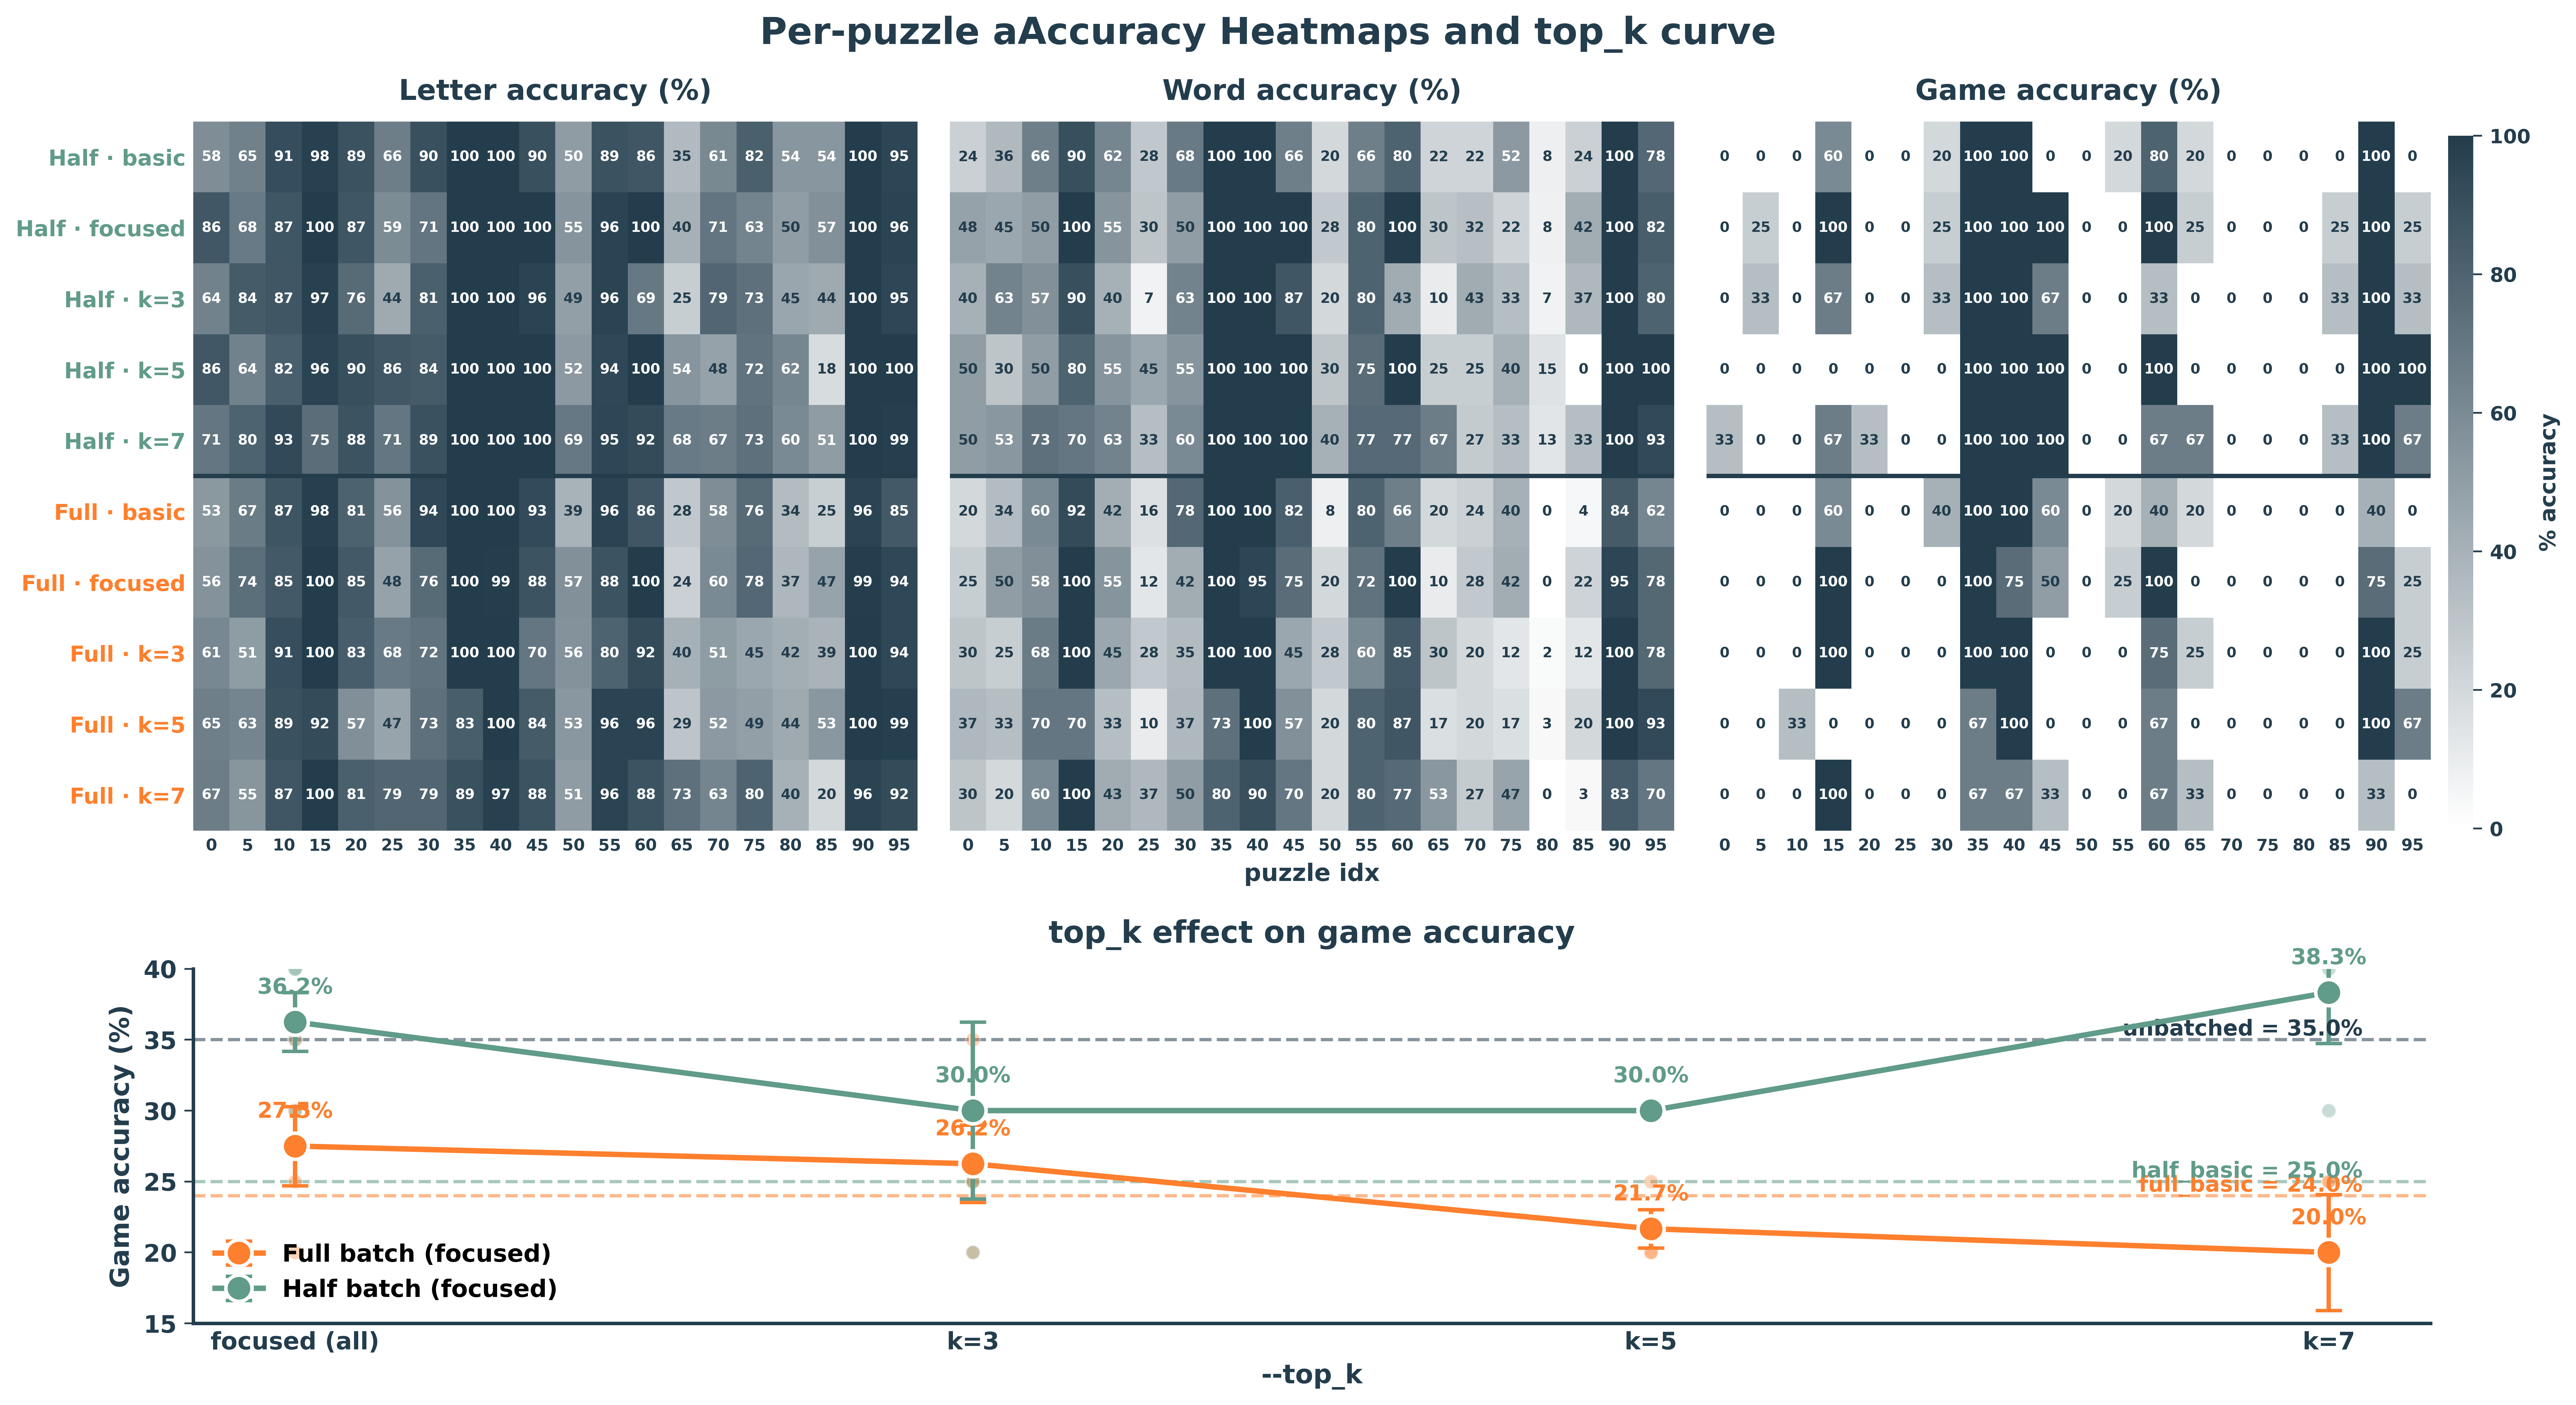

In [45]:
from matplotlib.colors import LinearSegmentedColormap

# 10 configs in display order: 5 half + 5 full
heatmap_configs = [
    ('Half · basic',    'half', 'cw_gem31_tot_half_basic_s100_prune_backtrack_papersplit*.jsonl'),
    ('Half · focused',  'half', 'cw_gem31_tot_half_focused_s100_prune_backtrack_papersplit*.jsonl'),
    ('Half · k=3',      'half', 'cw_gem31_tot_half_focused_k3_s100_prune_backtrack_papersplit*.jsonl'),
    ('Half · k=5',      'half', 'cw_gem31_tot_half_focused_k5_s100_prune_backtrack_papersplit*.jsonl'),
    ('Half · k=7',      'half', 'cw_gem31_tot_half_focused_k7_s100_prune_backtrack_papersplit*.jsonl'),
    ('Full · basic',    'full', 'cw_gem31_tot_full_basic_s100_prune_backtrack_papersplit*.jsonl'),
    ('Full · focused',  'full', 'cw_gem31_tot_full_focused_s100_prune_backtrack_papersplit*.jsonl'),
    ('Full · k=3',      'full', 'cw_gem31_tot_full_focused_k3_s100_prune_backtrack_papersplit*.jsonl'),
    ('Full · k=5',      'full', 'cw_gem31_tot_full_focused_k5_s100_prune_backtrack_papersplit*.jsonl'),
    ('Full · k=7',      'full', 'cw_gem31_tot_full_focused_k7_s100_prune_backtrack_papersplit*.jsonl'),
]

def per_puzzle_means(pattern):
    """Per puzzle idx, average (letter, word, game) % across every row of every matching file."""
    by_idx = {}
    for fp in sorted(glob.glob(str(RUNS / pattern))):
        with open(fp) as f:
            for line in f:
                if not line.strip(): continue
                r = json.loads(line)
                l, w, g = grid_metrics(r['grid'], r['ground_truth'])
                by_idx.setdefault(r['idx'], []).append((l*100, w*100, g*100))
    return {i: tuple(statistics.mean(vals) for vals in zip(*pairs))
            for i, pairs in by_idx.items()}

# Compute per-config per-puzzle metrics
all_idx_set = set()
puzzle_data = []
for label, group, pat in heatmap_configs:
    pp = per_puzzle_means(pat)
    puzzle_data.append((label, group, pp))
    all_idx_set.update(pp.keys())
all_idx = sorted(all_idx_set)
n_rows, n_cols = len(heatmap_configs), len(all_idx)

M_letter = np.full((n_rows, n_cols), np.nan)
M_word   = np.full((n_rows, n_cols), np.nan)
M_game   = np.full((n_rows, n_cols), np.nan)
for i, (_, _, pp) in enumerate(puzzle_data):
    for j, idx in enumerate(all_idx):
        if idx in pp:
            M_letter[i, j], M_word[i, j], M_game[i, j] = pp[idx]

fig = plt.figure(figsize=(16, 9), dpi=500)

gs = fig.add_gridspec(
    2, 3,
    height_ratios=[1.60, 0.8],
    hspace=0.26,          # ↓ reduce vertical gap
    wspace=0.045,         # ↓ reduce gap between heatmaps
    left=0.075,
    right=0.965,          # leave space for colorbar
    top=0.925,
    bottom=0.075
)
cmap = LinearSegmentedColormap.from_list('charcoal_fade', ['white', CHARCOAL])

def render_heatmap(ax, M, title, *, show_yticks=True):
    ax.imshow(M, aspect='auto', cmap=cmap, vmin=0, vmax=100)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            v = M[i, j]
            if np.isnan(v): continue
            ax.text(j, i, f'{int(round(v))}', ha='center', va='center',
                    fontsize=6.5, fontweight='bold',
                    color='white' if v > 50 else CHARCOAL)
    ax.axhline(4.5, color=CHARCOAL, linewidth=2.0)  # half/full separator
    ax.set_xticks(range(M.shape[1]))
    ax.set_xticklabels([str(i) for i in all_idx], fontsize=7.5)
    if show_yticks:
        ax.set_yticks(range(M.shape[0]))
        ax.set_yticklabels([c[0] for c in heatmap_configs], fontsize=10)
        for tick, (_, group, _) in zip(ax.get_yticklabels(), heatmap_configs):
            tick.set_color(SEAGRASS if group == 'half' else PUMPKIN)
    else:
        ax.set_yticks([])
    ax.tick_params(axis='x', length=0); ax.tick_params(axis='y', length=0)
    for s in ('top','right','left','bottom'):
        ax.spines[s].set_visible(False)
    ax.set_title(title, pad=10, fontsize=13)

ax_letter = fig.add_subplot(gs[0, 0])
ax_word   = fig.add_subplot(gs[0, 1])
ax_game   = fig.add_subplot(gs[0, 2])
render_heatmap(ax_letter, M_letter, 'Letter accuracy (%)', show_yticks=True)
render_heatmap(ax_word,   M_word,   'Word accuracy (%)',   show_yticks=False)
render_heatmap(ax_game,   M_game,   'Game accuracy (%)',   show_yticks=False)
ax_word.set_xlabel('puzzle idx', fontsize=11)

# Bottom: top_k curve (reuses full_m / half_m / etc. computed earlier)
ax_tk = fig.add_subplot(gs[1, :])
x_k = np.arange(len(ks))
ax_tk.errorbar(x_k, full_m, yerr=full_se, color=PUMPKIN, marker='o', markersize=12,
               markeredgecolor='white', markeredgewidth=1.6, linewidth=2.5,
               capsize=6, elinewidth=2, zorder=3, label='Full batch (focused)')
ax_tk.errorbar(x_k, half_m, yerr=half_se, color=SEAGRASS, marker='o', markersize=12,
               markeredgecolor='white', markeredgewidth=1.6, linewidth=2.5,
               capsize=6, elinewidth=2, zorder=3, label='Half batch (focused)')
for xi, vs in zip(x_k, full_runs_per_k):
    if vs: ax_tk.scatter([xi]*len(vs), vs, s=42, color=PUMPKIN, alpha=0.35, edgecolor='white', linewidth=0.8, zorder=2)
for xi, vs in zip(x_k, half_runs_per_k):
    if vs: ax_tk.scatter([xi]*len(vs), vs, s=42, color=SEAGRASS, alpha=0.35, edgecolor='white', linewidth=0.8, zorder=2)
for xi, m in zip(x_k, full_m):
    if not np.isnan(m): ax_tk.text(xi, m + 2.0, f'{m:.1f}%', ha='center', fontsize=10, color=PUMPKIN, fontweight='bold')
for xi, m in zip(x_k, half_m):
    if not np.isnan(m): ax_tk.text(xi, m + 2.0, f'{m:.1f}%', ha='center', fontsize=10, color=SEAGRASS, fontweight='bold')
for label, color, m in [('full_basic', PUMPKIN, cells['full_basic']['game_mean']),
                         ('half_basic', SEAGRASS, cells['half_basic']['game_mean']),
                         ('unbatched',  CHARCOAL, cells['unbatched']['game_mean'])]:
    ax_tk.axhline(m, color=color, linestyle='--', linewidth=1.5, alpha=0.55, zorder=1)
    ax_tk.text(len(ks)-0.95, m + 0.3, f'{label} = {m:.1f}%', color=color, fontsize=10, fontweight='bold', ha='right')
ax_tk.set_xticks(x_k); ax_tk.set_xticklabels(['focused (all)', 'k=3', 'k=5', 'k=7'])
ax_tk.set_xlabel('--top_k')
ax_tk.set_ylabel('Game accuracy (%)')
ax_tk.set_title('top_k effect on game accuracy', pad=12)
ax_tk.set_ylim(15, 40)
ax_tk.legend(loc='lower left')

# Shared colorbar for the heatmap row
cbar_ax = fig.add_axes([0.972, 0.425, 0.010, 0.49])
sm = mpl.cm.ScalarMappable(
    norm=mpl.colors.Normalize(vmin=0, vmax=100),
    cmap=cmap
)
cb = fig.colorbar(sm, cax=cbar_ax)
cb.set_label('% accuracy', fontsize=10, fontweight='bold', color=CHARCOAL)
cb.ax.tick_params(labelsize=9, colors=CHARCOAL)
cb.outline.set_visible(False)

fig.suptitle(' Per-puzzle aAccuracy Heatmaps and top_k curve',
             fontsize=17, fontweight='bold', color=CHARCOAL, y=1.0)
plt.show()